# A methylome language model — makemore, but for DNA methylation

A **Karpathy-`makemore`-style** progression that builds an **autoregressive** model on GDSC gene-level
methylation, with every **forward** and **backward** pass made explicit and visualized with matplotlib.

**The reframing.** `makemore` models names as sequences of characters: it learns \(p(c_i \mid c_{<i})\).
We do the same to a *methylome*. Take an ordered panel of genes, bin each gene's continuous beta
\(\in[0,1]\) into `K` discrete levels → **tokens**, and treat each cell line as a **sequence of tokens**.
The model learns \(p(\text{level}_i \mid \text{context})\) — a generative model of how methylation levels
flow from gene to gene (co-methylation structure).

**Honest caveat.** Unlike letters in a word, our gene order is a *fixed panel order*, not an intrinsic
sequence. The autoregressive factorization is still valid for any fixed order, and what it learns is real:
**co-methylation** — genes whose methylation moves together. A richer model would add gene-identity
(positional) embeddings and order genes by genomic coordinate.

**The progression (each stage makes forward+backward explicit):**
1. Tokenize the methylome (continuous beta → discrete levels).
2. **Bigram count model** — the no-gradients floor; visualize the count matrix.
3. **Bigram neural net** — one matmul + softmax. *Show logits → probs → loss (forward), then `.grad` (backward).*
4. **MLP (Bengio)** — embeddings + context. Karpathy-style **activation & gradient histograms**.
5. **Sample** a synthetic methylome from the trained model.
6. **Does the AR representation predict drug response?** — the GPT-style payoff, tested against AUC.

> The notebook loads real GDSC data via the `strata` loaders if present, and **falls back to synthetic
> data** otherwise so every cell runs.

In [1]:
import os, math
os.environ.setdefault("MPLCONFIGDIR", os.path.join(os.getcwd(), ".mplcache"))
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(1337)
np.random.seed(1337)
g = torch.Generator().manual_seed(1337)

# ---- knobs ----
N_GENES   = 64    # genes in the ordered panel -> sequence length
K_LEVELS  = 10    # methylation levels (quantile bins) -> vocabulary size
DRUG      = "Palbociclib"   # used only in the final drug-response section
plt.rcParams["figure.dpi"] = 110
print(f"panel length (seq len) = {N_GENES} genes | vocab = {K_LEVELS} methylation levels")

panel length (seq len) = 64 genes | vocab = 10 methylation levels


## Stage 0 — Load methylation (and one drug's AUC for later)

Real GDSC betas via the `strata` loaders if available; otherwise a synthetic methylome with planted
co-methylation structure so the autoregressive model has something real to learn.

In [2]:
def load_real():
    """beta matrix (lines x genes) + aligned AUC Series for DRUG, via strata loaders."""
    from strata.data import gdsc
    meth = gdsc.load_gdsc_methylation()
    drug = gdsc.load_gdsc_drug_response()
    d = drug[drug["drug_name"].str.lower() == DRUG.lower()]
    auc = d.groupby("COSMIC_ID")["auc"].mean()
    common = meth.index.intersection(auc.index)
    return meth.loc[common], auc.loc[common]

def make_synthetic(n_lines=900, n_genes=400, seed=1337):
    """Synthetic betas in [0,1] with block co-methylation + a sensitivity axis."""
    rng = np.random.default_rng(seed)
    blocks = rng.integers(0, 8, size=n_genes)            # genes share a block latent
    latent = rng.normal(0, 1, size=(n_lines, 8))
    z = latent[:, blocks] + rng.normal(0, 0.6, size=(n_lines, n_genes))
    beta = 1 / (1 + np.exp(-z))                          # squash to (0,1)
    import pandas as pd
    cols = [f"GENE{i}" for i in range(n_genes)]
    idx = [f"L{i}" for i in range(n_lines)]
    meth = pd.DataFrame(beta, index=idx, columns=cols)
    auc = pd.Series(0.9 - 0.15 * (beta[:, :20].mean(1) - 0.5) + rng.normal(0, 0.04, n_lines),
                    index=idx, name="auc")
    return meth, auc

try:
    meth, auc = load_real()
    SOURCE = "REAL GDSC"
except Exception as e:
    print(f"Real data unavailable ({type(e).__name__}: {e}); using synthetic.")
    meth, auc = make_synthetic()
    SOURCE = "SYNTHETIC"

print(f"[{SOURCE}] methylation: {meth.shape[0]} cell lines x {meth.shape[1]} genes")
print(f"AUC for {DRUG}: {auc.shape[0]} lines (mean={auc.mean():.3f})")
meth.iloc[:3, :5]

[REAL GDSC] methylation: 968 cell lines x 14608 genes
AUC for Palbociclib: 968 lines (mean=0.922)


,A1BG,A2BP1,A2LD1,A4GALT,AAAS
COSMIC_ID,,,,,
905975,0.84968,0.27184,0.88745,0.55872,0.20010
946356,0.74876,0.53834,0.77843,0.35036,0.15404
1299069,0.61620,0.45095,0.79393,0.38285,0.20609


## Stage 1 — Tokenize the methylome

Pick the `N_GENES` most-variable genes (the informative ones), then **quantile-bin** each gene's beta
into `K_LEVELS` levels so every level is equally populated (like a balanced character vocabulary).
Each cell line becomes a sequence of `N_GENES` integer tokens in `0..K_LEVELS-1`.

token matrix: (968, 64) | values in (0, 9)
example methylome (first line, first 24 genes):
[8, 4, 7, 6, 4, 8, 6, 1, 6, 8, 7, 3, 4, 3, 0, 5, 6, 7, 4, 8, 1, 9, 3, 8]


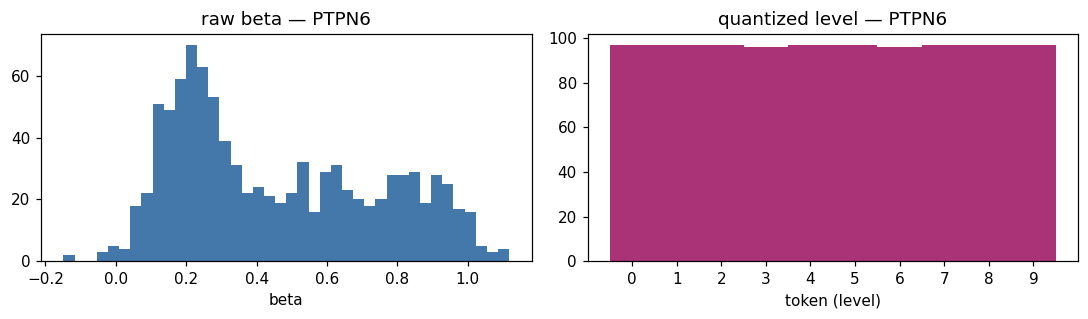

In [3]:
# --- pick the gene panel (most-variable genes) and fix its order ---
var = meth.var(axis=0)
panel = var.sort_values(ascending=False).head(N_GENES).index.tolist()
B = meth[panel].to_numpy(dtype=np.float64)        # lines x N_GENES, betas in [0,1]

# --- quantile-bin each gene into K_LEVELS tokens (per-gene edges) ---
edges = np.quantile(B, np.linspace(0, 1, K_LEVELS + 1), axis=0)   # (K+1, N_GENES)
tokens = np.zeros_like(B, dtype=np.int64)
for j in range(N_GENES):
    e = np.unique(edges[:, j])
    tokens[:, j] = np.clip(np.digitize(B[:, j], e[1:-1]), 0, K_LEVELS - 1)

tokens = torch.tensor(tokens, dtype=torch.long)   # (n_lines, N_GENES)
print("token matrix:", tuple(tokens.shape), "| values in", (int(tokens.min()), int(tokens.max())))
print("example methylome (first line, first 24 genes):")
print(tokens[0, :24].tolist())

# show the binning for one gene: continuous beta -> discrete level
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].hist(B[:, 0], bins=40, color="#4477aa"); ax[0].set_title(f"raw beta — {panel[0]}"); ax[0].set_xlabel("beta")
ax[1].hist(tokens[:, 0].numpy(), bins=np.arange(K_LEVELS + 1) - 0.5, color="#aa3377")
ax[1].set_title(f"quantized level — {panel[0]}"); ax[1].set_xlabel("token (level)"); ax[1].set_xticks(range(K_LEVELS))
plt.tight_layout(); plt.show()

## Stage 2 — Bigram count model (the no-gradients floor)

`makemore`'s first model. With a special **START** token (id `K_LEVELS`), count every adjacent
`(level_i -> level_{i+1})` transition across all cell lines into a matrix `N`, normalize rows to
probabilities, and score the data by negative log-likelihood. No gradients yet — pure counting.

bigram average NLL (loss) = 2.2677   (uniform baseline = 2.3979)


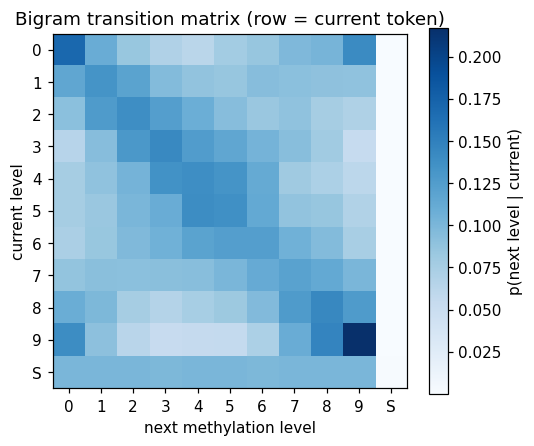

In [4]:
START = K_LEVELS                 # extra token that begins every sequence
V = K_LEVELS + 1                 # vocab incl. START

# prepend START to every methylome -> (n_lines, N_GENES+1)
seqs = torch.cat([torch.full((tokens.shape[0], 1), START), tokens], dim=1)

# count transitions current -> next
N = torch.zeros((V, V), dtype=torch.int64)
for s in seqs:
    for a, b in zip(s[:-1], s[1:]):
        N[a, b] += 1

P = (N + 1).float()              # +1 smoothing
P /= P.sum(1, keepdim=True)

# negative log-likelihood of the data under the bigram model
nll, cnt = 0.0, 0
for s in seqs:
    for a, b in zip(s[:-1], s[1:]):
        nll += -torch.log(P[a, b]); cnt += 1
print(f"bigram average NLL (loss) = {nll/cnt:.4f}   (uniform baseline = {math.log(V):.4f})")

plt.figure(figsize=(5.2, 4.4))
plt.imshow(P.numpy(), cmap="Blues")
plt.colorbar(label="p(next level | current)")
plt.xlabel("next methylation level"); plt.ylabel("current level")
plt.title("Bigram transition matrix (row = current token)")
plt.xticks(range(V), list(range(K_LEVELS)) + ["S"]); plt.yticks(range(V), list(range(K_LEVELS)) + ["S"])
plt.show()

## Stage 3 — Bigram as a neural net: one **forward** and one **backward** pass, made explicit

Same bigram, now learned by gradient descent (`makemore` part 2). The network is a single weight matrix
`W` (`V x V`): one-hot the current token, `logits = xenc @ W`, softmax to probabilities, and the loss is
the mean negative log-likelihood of the true next token.

Below we run **one forward pass** (printing logits → probs → loss) and **one backward pass**
(`loss.backward()`, then visualize `W.grad`) before training in a loop.

61,952 bigram examples
FORWARD: logits (61952, 11) | example probs (first token): [0.073 0.182 0.009 0.035 0.051 0.246 0.022 0.047 0.25  0.015 0.069]
FORWARD: initial loss = 2.8684
BACKWARD: dW shape = (11, 11) | grad norm = 0.1056 | grad mean = +0.00000


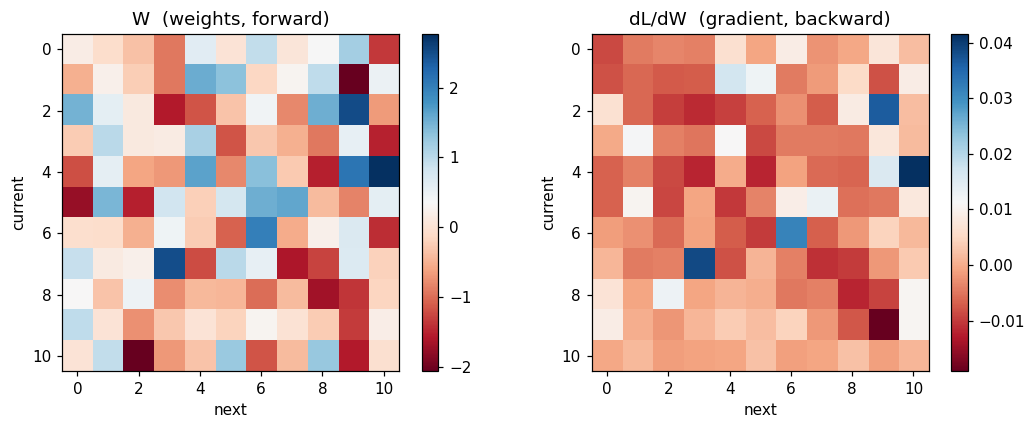

In [5]:
# build the bigram training set: xs = current token, ys = next token
xs, ys = [], []
for s in seqs:
    xs.append(s[:-1]); ys.append(s[1:])
xs = torch.cat(xs); ys = torch.cat(ys)
print(f"{xs.nelement():,} bigram examples")

W = torch.randn((V, V), generator=g, requires_grad=True)

# ---------------- ONE FORWARD PASS ----------------
xenc = F.one_hot(xs, num_classes=V).float()   # (Nbigrams, V)
logits = xenc @ W                             # (Nbigrams, V)  log-counts
counts = logits.exp()
probs = counts / counts.sum(1, keepdim=True)  # softmax -> p(next | current)
loss = -probs[torch.arange(xs.nelement()), ys].log().mean()
print("FORWARD: logits", tuple(logits.shape),
      "| example probs (first token):", probs[0].detach().numpy().round(3))
print(f"FORWARD: initial loss = {loss.item():.4f}")

# ---------------- ONE BACKWARD PASS ----------------
W.grad = None
loss.backward()
print(f"BACKWARD: dW shape = {tuple(W.grad.shape)} | "
      f"grad norm = {W.grad.norm().item():.4f} | grad mean = {W.grad.mean().item():+.5f}")

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
im0 = ax[0].imshow(W.detach().numpy(), cmap="RdBu"); ax[0].set_title("W  (weights, forward)")
fig.colorbar(im0, ax=ax[0], fraction=0.046)
im1 = ax[1].imshow(W.grad.numpy(), cmap="RdBu"); ax[1].set_title("dL/dW  (gradient, backward)")
fig.colorbar(im1, ax=ax[1], fraction=0.046)
for a in ax: a.set_xlabel("next"); a.set_ylabel("current")
plt.tight_layout(); plt.show()

final learned-bigram loss = 2.2711  (count-model NLL was 2.2677)


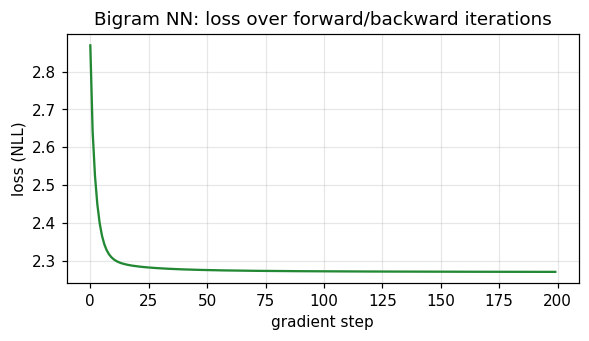

In [6]:
# now loop forward+backward+update and watch the loss fall to the count-model floor
losses = []
for step in range(200):
    xenc = F.one_hot(xs, num_classes=V).float()
    logits = xenc @ W
    counts = logits.exp(); probs = counts / counts.sum(1, keepdim=True)
    loss = -probs[torch.arange(xs.nelement()), ys].log().mean() + 0.001 * (W**2).mean()
    W.grad = None
    loss.backward()              # backward pass
    W.data += -25 * W.grad       # gradient-descent step
    losses.append(loss.item())

print(f"final learned-bigram loss = {losses[-1]:.4f}  (count-model NLL was {nll/cnt:.4f})")
plt.figure(figsize=(6, 3))
plt.plot(losses, color="#228833"); plt.xlabel("gradient step"); plt.ylabel("loss (NLL)")
plt.title("Bigram NN: loss over forward/backward iterations"); plt.grid(alpha=0.3); plt.show()

## Stage 4 — MLP with embeddings + context (Bengio 2003 / `makemore` part 3)

Now the model sees the previous `BLOCK` tokens, not just one. Each token is embedded into a learned
vector; the context embeddings are concatenated and passed through a `tanh` hidden layer to predict the
next level. We train on minibatches and — Karpathy's signature diagnostic — plot **histograms of the
forward-pass activations** (is `tanh` saturating?) and the **backward-pass gradients** per parameter.

In [7]:
BLOCK   = 4     # context length (genes)
N_EMBD  = 8     # embedding dim per token
N_HID   = 128   # hidden units

# build (context -> next token) examples, padding the start with START
Xc, Yc = [], []
for s in seqs:                          # s already has a START at position 0
    ctx = [START] * BLOCK
    for tok in s[1:].tolist():          # predict each real token from BLOCK preceding
        Xc.append(ctx.copy()); Yc.append(tok)
        ctx = ctx[1:] + [tok]
Xc = torch.tensor(Xc); Yc = torch.tensor(Yc)

# split lines->examples into train/val by a simple 90/10 example split
n = Xc.shape[0]; perm = torch.randperm(n, generator=g)
ntr = int(0.9 * n)
tr_i, va_i = perm[:ntr], perm[ntr:]
print(f"MLP dataset: {n:,} examples | block={BLOCK} | embd={N_EMBD} | hid={N_HID}")

# parameters
C  = torch.randn((V, N_EMBD), generator=g)
W1 = torch.randn((BLOCK * N_EMBD, N_HID), generator=g) * (5/3) / (BLOCK*N_EMBD)**0.5  # Kaiming-ish
b1 = torch.zeros(N_HID)
W2 = torch.randn((N_HID, V), generator=g) * 0.01
b2 = torch.zeros(V)
params = [C, W1, b1, W2, b2]
for p in params: p.requires_grad_(True)
print("total params:", sum(p.nelement() for p in params))

MLP dataset: 61,952 examples | block=4 | embd=8 | hid=128
total params: 5731


train loss = 2.1760 | val loss = 2.1974 | bigram floor was 2.2711


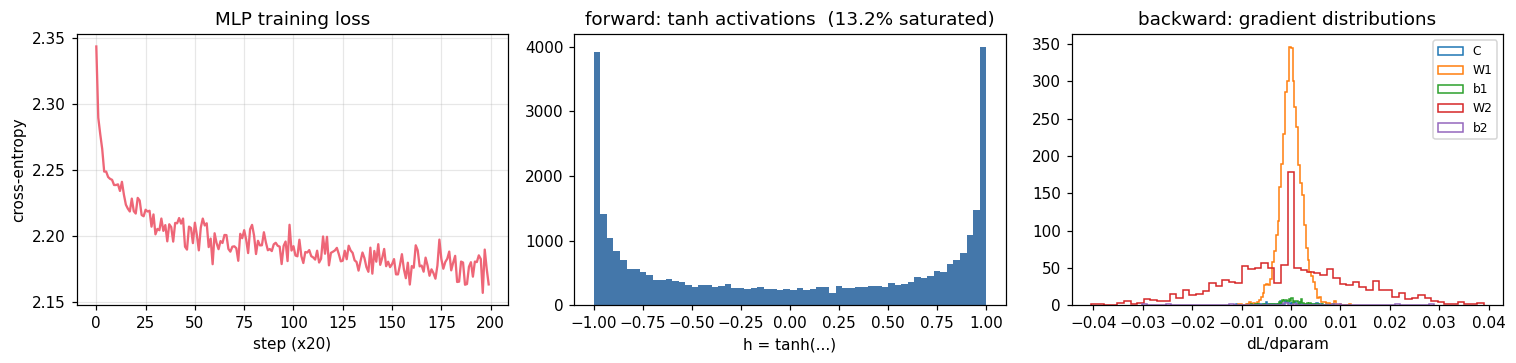

In [8]:
def forward(idx, return_h=False):
    emb = C[idx]                              # (B, BLOCK, N_EMBD)
    h = torch.tanh(emb.view(emb.shape[0], -1) @ W1 + b1)   # (B, N_HID)  <- activations of interest
    logits = h @ W2 + b2
    return (logits, h) if return_h else logits

STEPS, BS, LR = 4000, 256, 0.1
lossi, last_h = [], None
for step in range(STEPS):
    bi = tr_i[torch.randint(0, tr_i.shape[0], (BS,), generator=g)]
    logits, h = forward(Xc[bi], return_h=True)
    loss = F.cross_entropy(logits, Yc[bi])
    for p in params: p.grad = None
    loss.backward()                            # backward pass
    lr = LR if step < 3000 else LR * 0.1
    for p in params: p.data += -lr * p.grad
    lossi.append(loss.item())
    if step == STEPS - 1: last_h = h.detach()

with torch.no_grad():
    val_loss = F.cross_entropy(forward(Xc[va_i]), Yc[va_i]).item()
print(f"train loss = {np.mean(lossi[-200:]):.4f} | val loss = {val_loss:.4f} | "
      f"bigram floor was {losses[-1]:.4f}")

fig, ax = plt.subplots(1, 3, figsize=(14, 3.4))
ax[0].plot(torch.tensor(lossi).view(-1, 20).mean(1), color="#ee6677")
ax[0].set_title("MLP training loss"); ax[0].set_xlabel("step (x20)"); ax[0].set_ylabel("cross-entropy"); ax[0].grid(alpha=0.3)
# FORWARD-pass activations: tanh saturation check
ax[1].hist(last_h.view(-1).numpy(), bins=60, color="#4477aa")
sat = (last_h.abs() > 0.99).float().mean().item() * 100
ax[1].set_title(f"forward: tanh activations  ({sat:.1f}% saturated)"); ax[1].set_xlabel("h = tanh(...)")
# BACKWARD-pass gradients per parameter tensor
for p, name in zip(params, ["C", "W1", "b1", "W2", "b2"]):
    ax[2].hist(p.grad.view(-1).numpy(), bins=60, histtype="step", label=name)
ax[2].set_title("backward: gradient distributions"); ax[2].set_xlabel("dL/dparam"); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

## Stage 5 — Sample a synthetic methylome

Exactly `makemore`'s sampling loop: start from the `START` token and autoregressively draw the next
methylation level from the model's predicted distribution, feeding each draw back as context. The result
is a generated `N_GENES`-long methylome — a sequence the model thinks is plausible.

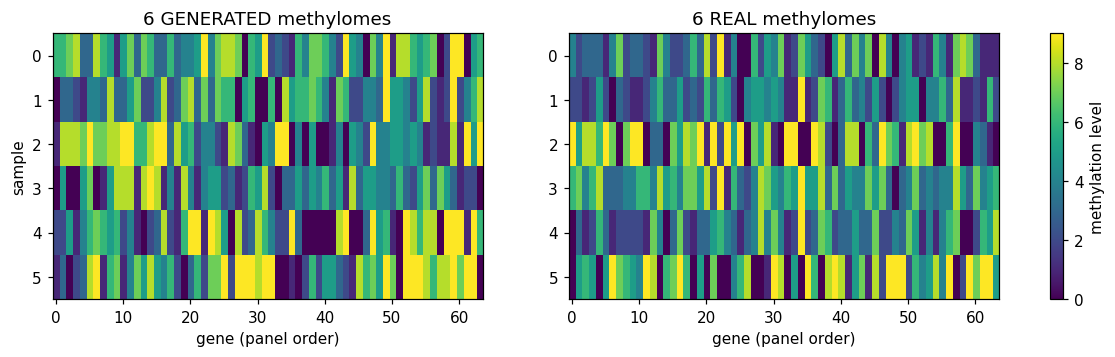

generated example (levels): [6, 6, 7, 8, 3, 3, 8, 6, 5, 1, 5, 7, 3, 7, 6, 3, 3, 6, 3, 4, 4, 5, 9, 4] ...


In [9]:
@torch.no_grad()
def sample_methylome(seed=0):
    gg = torch.Generator().manual_seed(seed)
    ctx = [START] * BLOCK
    out = []
    for _ in range(N_GENES):
        logits = forward(torch.tensor([ctx]))
        p = F.softmax(logits, dim=1)
        tok = torch.multinomial(p, 1, generator=gg).item()
        out.append(tok); ctx = ctx[1:] + [tok]
    return out

gen = [sample_methylome(s) for s in range(6)]
real = tokens[torch.randperm(tokens.shape[0], generator=g)[:6]].tolist()

fig, ax = plt.subplots(1, 2, figsize=(12, 3.2))
ax[0].imshow(gen, cmap="viridis", aspect="auto", vmin=0, vmax=K_LEVELS-1)
ax[0].set_title("6 GENERATED methylomes"); ax[0].set_xlabel("gene (panel order)"); ax[0].set_ylabel("sample")
im = ax[1].imshow(real, cmap="viridis", aspect="auto", vmin=0, vmax=K_LEVELS-1)
ax[1].set_title("6 REAL methylomes"); ax[1].set_xlabel("gene (panel order)")
fig.colorbar(im, ax=ax, fraction=0.025, label="methylation level")
plt.show()
print("generated example (levels):", gen[0][:24], "...")

## Stage 6 — Does the autoregressive representation predict drug response?

The GPT-style payoff: a model pretrained to *predict methylation* should learn features useful for a
*downstream* task. We take the trained MLP's hidden layer as a methylome encoder: for each cell line,
average its per-gene hidden activations into one vector, then run a cell-line-blind RidgeCV to predict
`{DRUG}` AUC from those AR features — versus the global-mean baseline.

In [10]:
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import KFold
from scipy.stats import pearsonr

# per-line AR feature = mean hidden activation across that line's gene contexts
@torch.no_grad()
def line_features(seq_tokens):
    ctx = [START] * BLOCK
    ctxs = []
    for tok in seq_tokens.tolist():
        ctxs.append(ctx.copy()); ctx = ctx[1:] + [tok]
    _, h = forward(torch.tensor(ctxs), return_h=True)   # (N_GENES, N_HID)
    return h.mean(0)                                     # (N_HID,)

Z = torch.stack([line_features(tokens[i]) for i in range(tokens.shape[0])]).numpy()
y = auc.reindex(meth.index).to_numpy(dtype=np.float64)
mask = ~np.isnan(y); Z, y = Z[mask], y[mask]
print(f"AR features Z: {Z.shape} | targets: {y.shape}")

kf = KFold(5, shuffle=True, random_state=1337)
base_r, ar_r = [], []
for tr, te in kf.split(Z):
    base = np.full(te.shape[0], y[tr].mean())
    m = RidgeCV(alphas=np.logspace(-2, 4, 10)).fit(Z[tr], y[tr])
    pred = m.predict(Z[te])
    ar_r.append(pearsonr(y[te], pred)[0] if np.ptp(pred) else np.nan)
print(f"AR-feature -> AUC   Pearson r = {np.nanmean(ar_r):+.3f}  (5-fold, cell-line-blind)")
print("Global-mean baseline r is 0 by construction (constant prediction).")
print("\n=> If r>0, the methylation language model's representation carries real drug-response signal —")
print("   the same transfer-learning logic as GPT pretraining, applied to the methylome.")

AR features Z: (968, 128) | targets: (968,)
AR-feature -> AUC   Pearson r = +0.395  (5-fold, cell-line-blind)
Global-mean baseline r is 0 by construction (constant prediction).

=> If r>0, the methylation language model's representation carries real drug-response signal —
   the same transfer-learning logic as GPT pretraining, applied to the methylome.


## Where this goes next

- **Gene identity & order.** Add positional/gene-identity embeddings and order the panel by genomic
  coordinate so the sequence captures *cis* co-methylation (CpG-island neighborhoods), not just a fixed panel.
- **Continuous tokens.** Replace the K-bin softmax with a mixture-density or Gaussian head to model betas
  directly, avoiding quantization loss.
- **Self-attention (`makemore` → GPT).** Swap the MLP for a small Transformer over the gene sequence;
  attention lets distant co-methylated genes inform each other.
- **Condition on context.** Prepend a cancer-type or drug token so the model becomes a *conditional*
  generator: `p(methylome | tissue)` or `p(response | methylome, drug)`.
- **Pretrain → fine-tune.** Pretrain the encoder on all ~1,000 methylomes (unsupervised), then fine-tune
  the Stage-6 head per drug. This is the route to beating the strong Ridge baselines when labels are scarce.